# 1. 커피OO 데이터 분석 

## 0. 환경 설정 및 데이터 로드


In [2]:
import pandas as pd 
import csv 
import os 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 
import koreanize_matplotlib

In [3]:
folder_path = os.path.join(os.getcwd(), 'data')
for file in os.listdir(folder_path):
    if file.startswith('d'):
        data_path = os.path.join(folder_path, file)
        raw_data = pd.read_csv(data_path)
cp_data_df = raw_data.copy()

In [4]:
# 데이터 확인 
cp_data_df.head()

,결제일시,결제일,결제년월,결제년,결제월,결제시간,결제시간대,요일,카테고리,수량,상품별 단가,상품명_추출,Hot/Ice,원두대분류,원두종류,원두용량,할인여부,취식 방법,매출
0,2022-02-10 10:03:28,2022-02-10,2022-02,2022,2,10:03:28,10,목요일,핸드드립,1,10000,과테말라 레드 파카마라,Hot,싱글,과테말라 레드 파카마라,-,-,-,10000
1,2022-02-10 10:03:28,2022-02-10,2022-02,2022,2,10:03:28,10,목요일,핸드드립,1,10500,콜롬비아 로꼬 소르베,Ice,싱글,콜롬비아 로꼬 소르베,-,-,-,10500
2,2022-02-10 10:03:28,2022-02-10,2022-02,2022,2,10:03:28,10,목요일,핸드드립,1,12000,니카라과 COE#1,Hot,싱글,니카라과 COE#1,-,-,-,12000
3,2022-02-10 10:13:57,2022-02-10,2022-02,2022,2,10:13:57,10,목요일,에스프레소,1,6500,슈퍼클린에스프레소,Hot,블렌딩,클래식,-,-,-,6500
4,2022-02-10 10:13:57,2022-02-10,2022-02,2022,2,10:13:57,10,목요일,에스프레소,1,6500,슈퍼클린에스프레소,Hot,블렌딩,쥬시,-,-,-,6500


In [5]:
cp_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153433 entries, 0 to 153432
Data columns (total 19 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   결제일시     153433 non-null  object
 1   결제일      153433 non-null  object
 2   결제년월     153433 non-null  object
 3   결제년      153433 non-null  int64 
 4   결제월      153433 non-null  int64 
 5   결제시간     153433 non-null  object
 6   결제시간대    153433 non-null  int64 
 7   요일       153433 non-null  object
 8   카테고리     153433 non-null  object
 9   수량       153433 non-null  int64 
 10  상품별 단가   153433 non-null  int64 
 11  상품명_추출   153433 non-null  object
 12  Hot/Ice  153433 non-null  object
 13  원두대분류    153433 non-null  object
 14  원두종류     153433 non-null  object
 15  원두용량     153433 non-null  object
 16  할인여부     153433 non-null  object
 17  취식 방법    153433 non-null  object
 18  매출       153433 non-null  int64 
dtypes: int64(6), object(13)
memory usage: 22.2+ MB


In [6]:
cp_data_df.shape

(153433, 19)

In [7]:
# 주말여부 컬럼 추가 
cp_data_df['주말 여부'] = np.where(cp_data_df['요일'].isin(['토요일', '일요일']), '주말', '평일')

# 계절 컬럼 추가 
cp_data_df['계절'] = np.where(cp_data_df['결제월'].isin([12, 1, 2]), '겨울',
                        np.where(cp_data_df['결제월'].isin([3, 4, 5]), '봄',
                        np.where(cp_data_df['결제월'].isin([6, 7, 8]), '여름', '가을')))

# 카페 운영시간 9시~18시 외 데이터 제거 
cp_data_df = cp_data_df.loc[~(cp_data_df['결제시간대'].isin([7, 8, 19, 18]))]

# "시" 단위 추가
cp_data_df['결제시간대'] = cp_data_df['결제시간대'].astype(str) + '시'

In [25]:
# 컬러 
sns.color_palette("Set3")

[(0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
 (1.0, 1.0, 0.7019607843137254),
 (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
 (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
 (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
 (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
 (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
 (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
 (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
 (0.7372549019607844, 0.5019607843137255, 0.7411764705882353),
 (0.8, 0.9215686274509803, 0.7725490196078432),
 (1.0, 0.9294117647058824, 0.43529411764705883)]

In [12]:
# 컬러 [파란색, 주황색]
colors1 = []
colors1.append(sns.color_palette("Set3")[5])
colors1.append(sns.color_palette("Set3")[4])

## 1-1. 카페 운영 시간과 매출의 관계 분석

### 1. 카페 월별 매출 추이

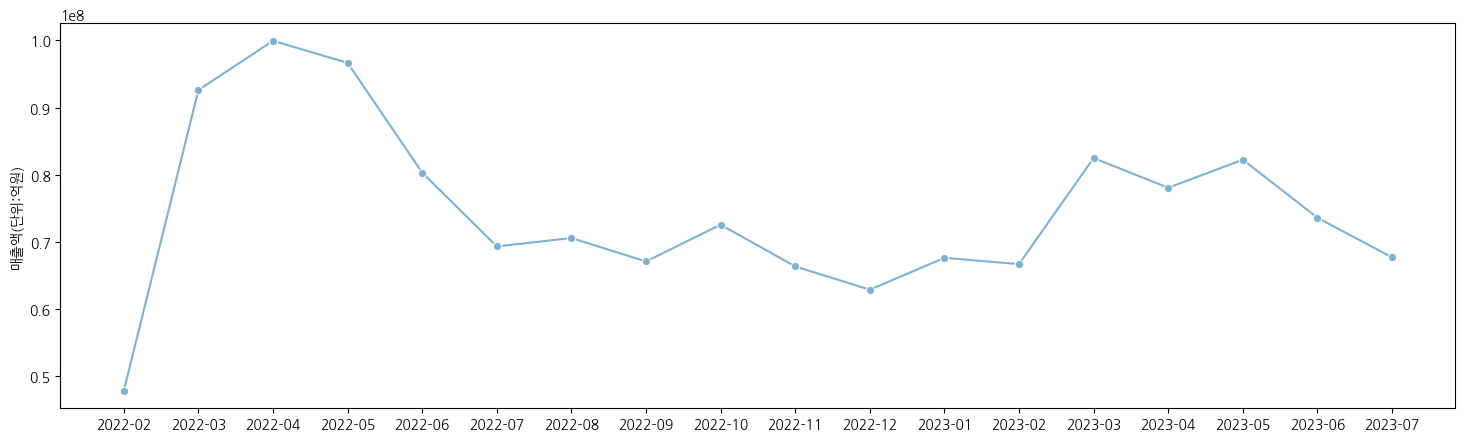

In [ ]:
# 카페 월별 매출 추이 

# 월별 매출 집계 
monthly_rev = cp_data_df.groupby(['결제년월'])['매출'].sum().reset_index(name='revenue')


# 월별 매출 추이 시각화
plt.figure(figsize=(18, 5))
sns.lineplot(data=monthly_rev, x='결제년월', y='revenue', marker='o', color=colors1[1])

plt.xlabel('')
plt.ylabel('매출액(단위:억원)')
plt.show()

### 2. 카페 시간대별 매출 추이 

#### 카페 시간대별 누적 매출액 변화

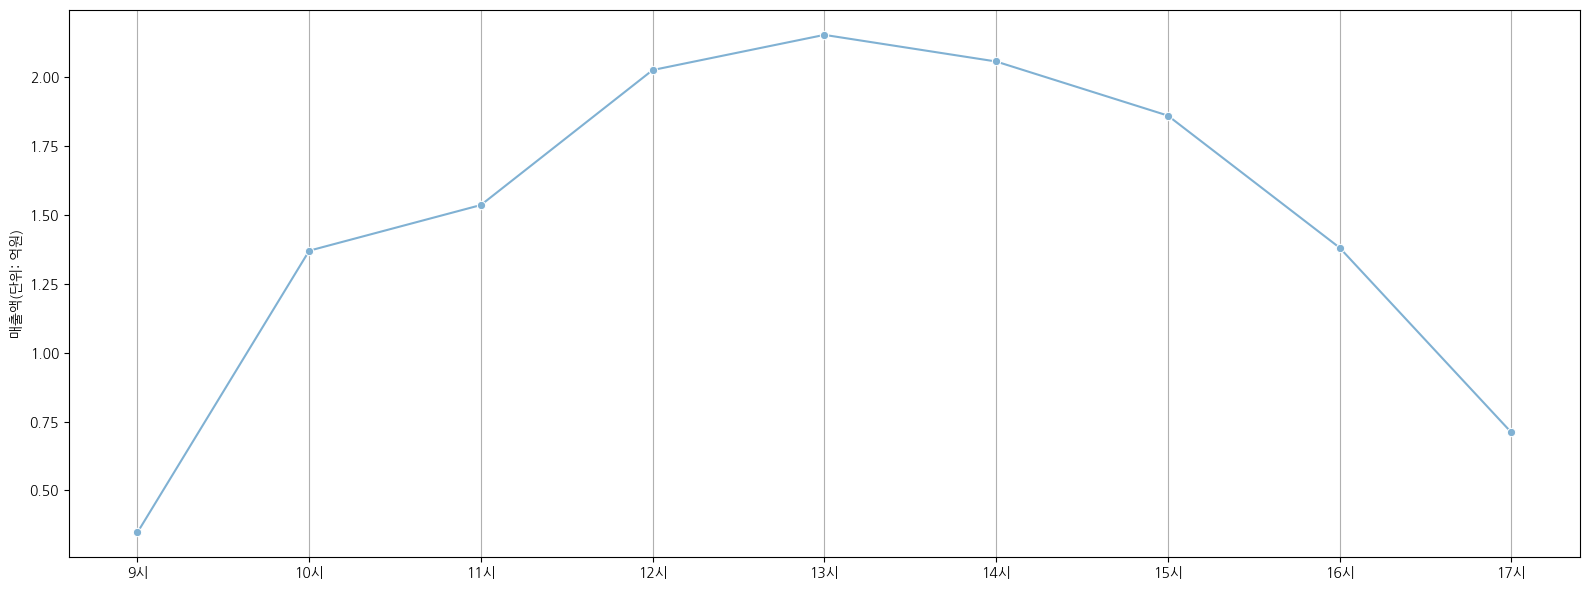

In [19]:
# 그룹화 
grouped_df = cp_data_df.groupby('결제시간대')['매출'].sum().reset_index(name='매출')

# 시간대 순서 지정
hour_order = ['9시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시', '18시']
grouped_df['결제시간대'] = pd.Categorical(grouped_df['결제시간대'], categories=hour_order, ordered=True)

# 정렬
grouped_df = grouped_df.sort_values('결제시간대')

# 단위 설졍
grouped_df['매출'] = grouped_df['매출']/1e8

# 시각화
plt.figure(figsize=(16, 6))
sns.lineplot(data=grouped_df, x='결제시간대', y='매출', marker='o', color=colors1[1])
plt.xlabel('')  # x축 라벨 비움
plt.ylabel('매출액(단위: 억원)')  # 필요시 y축 라벨 추가

plt.tight_layout()
plt.grid(axis='x')
plt.show()

In [20]:
# 메인 시간대 평균 매출 = 202,533,975
# 오픈시간(9시)  매출 == 34,744,800
# 마감시간(17시) 매출 == 71,079,400

#### 카페 평일/주말 시간대별 매출 변화 

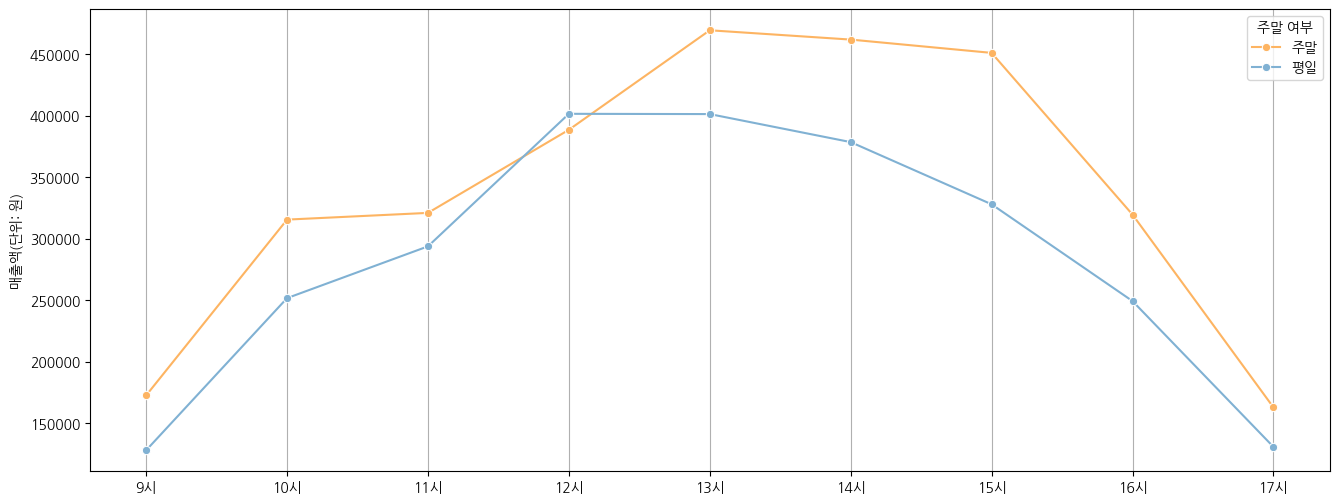

In [22]:
grouped_df = cp_data_df.groupby(['결제일', '결제시간대', '주말 여부'])['매출'].sum().reset_index(name='매출')
grouped2_df = grouped_df.groupby(['결제시간대', '주말 여부'])['매출'].mean().reset_index(name='매출')

# 시간대 순서 지정
hour_order = ['9시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시', '18시']
grouped2_df['결제시간대'] = pd.Categorical(grouped2_df['결제시간대'], categories=hour_order, ordered=True)


# 시각화 
plt.figure(figsize=(16, 6))
sns.lineplot(data=grouped2_df, x='결제시간대', y='매출', hue='주말 여부', palette=colors1, marker='o')
plt.xlabel('')
plt.ylabel('매출액(단위: 원)')
plt.grid(axis='x')
plt.show()

In [19]:
grouped2_df

,결제시간대,주말여부,매출
0,10시,주말,315413.071895
1,10시,평일,251603.966006
2,11시,주말,320869.480519
3,11시,평일,293680.563380
4,12시,주말,388390.909091
5,12시,평일,401370.224719
6,13시,주말,469248.051948
7,13시,평일,401153.501401
8,14시,주말,461688.961039
9,14시,평일,378389.606742


#### 평일/주말 시간대별 거래 건당 평균 금액 변화

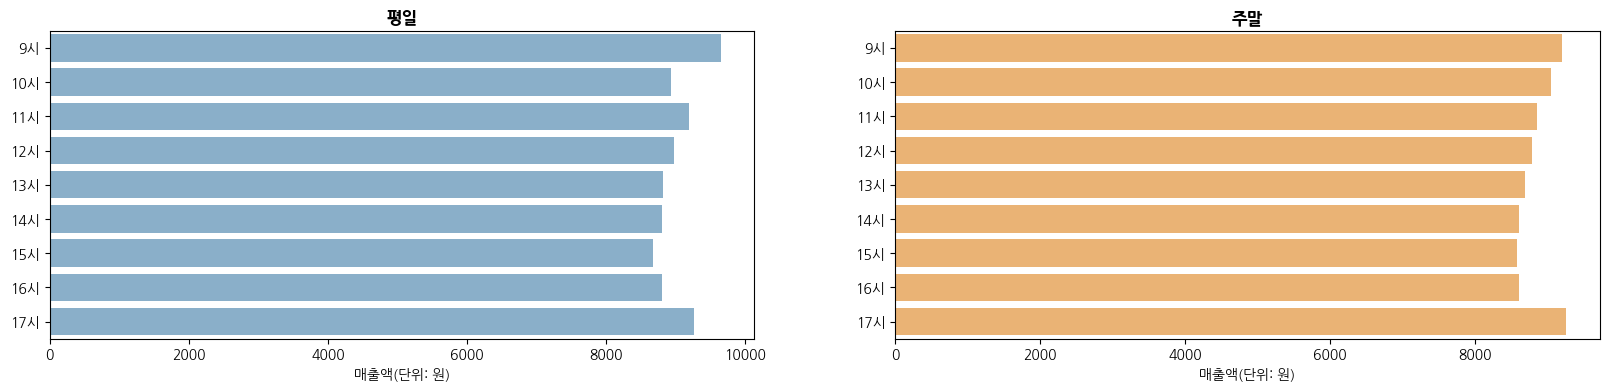

In [24]:
# 그룹화
grouped_df = cp_data_df.groupby(['결제시간대', '주말 여부'])['매출'].mean().reset_index(name='매출')

# 시간대 순서 지정
hour_order = ['9시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시']
grouped_df['결제시간대'] = pd.Categorical(grouped_df['결제시간대'], categories=hour_order, ordered=True)


# 시각화 
fig, axes = plt.subplots(1, 2, figsize=(20, 4))

# 평일 그래프 
ax1 = axes[0]

sns.barplot(data=grouped_df.loc[grouped_df['주말 여부'] == '평일'], x='매출', y='결제시간대', ax=ax1, color=colors1[1])

ax1.set_title('평일', fontsize=12, weight='bold')
ax1.set_xlabel('매출액(단위: 원)', fontsize=10)
ax1.set_ylabel('')

# 주말 그래프
ax2 = axes[1]
sns.barplot(data=grouped_df.loc[grouped_df['주말 여부'] == '주말'], x='매출', y='결제시간대', ax=ax2, color=colors1[0])
ax2.set_title('주말', fontsize=12, weight='bold')
ax2.set_xlabel('매출액(단위: 원)', fontsize=10)
ax2.set_ylabel('')

plt.show()


### 3. 카페 요일별 매출 추이 

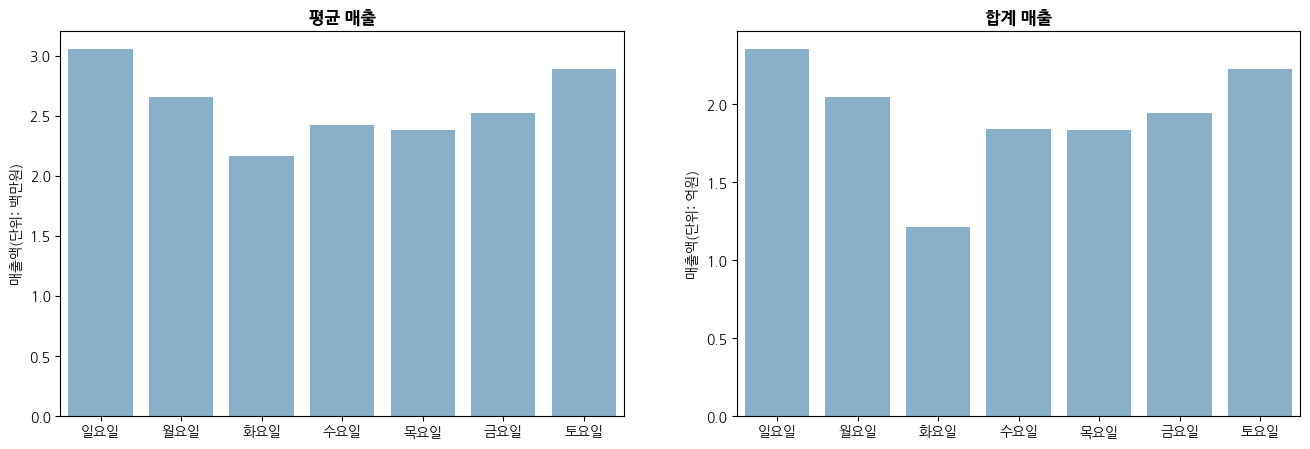

In [12]:
# 시간대 순서 지정
day_order = ['일요일', '월요일', '화요일', '수요일', '목요일', '금요일', '토요일']

# 평균 매출액 그룹화
grouped_df = cp_data_df.groupby(['결제일', '요일'])['매출'].sum().reset_index(name='매출')
mean_grouped_df = grouped_df.groupby(['요일'])['매출'].mean().reset_index(name='매출')
mean_grouped_df['요일'] = pd.Categorical(mean_grouped_df['요일'], categories=day_order, ordered=True)

# 합계 매출액 그룹화 
sum_grouped_df = cp_data_df.groupby(['요일'])['매출'].sum().reset_index(name='매출')
sum_grouped_df['요일'] = pd.Categorical(sum_grouped_df['요일'], categories=day_order, ordered=True)

# 단위 설정
mean_grouped_df['매출'] = mean_grouped_df['매출']/1e6
sum_grouped_df['매출'] = sum_grouped_df['매출']/1e8


# 시각화 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 평균 매출액
ax1 = axes[0]
sns.barplot(data=mean_grouped_df, x='요일', y='매출', ax=ax1, color=colors1[1])

ax1.set_title('평균 매출', fontsize=12, weight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('매출액(단위: 백만원)', fontsize=10)



# 합계 매출액 
ax2 = axes[1]
sns.barplot(data=sum_grouped_df, x='요일', y='매출', ax=ax2, color=colors1[1])
ax2.set_title('합계 매출', fontsize=12, weight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('매출액(단위: 억원)', fontsize=10)

plt.show()

### 4. 계절별 매출 추이 

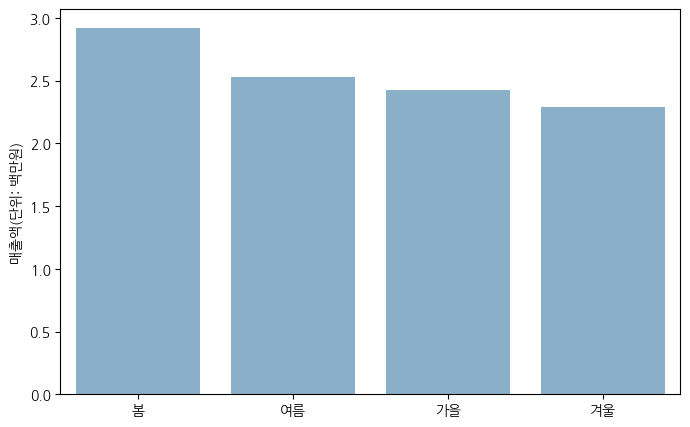

In [13]:
grouped_df = cp_data_df.groupby(['결제일', '계절'])['매출'].sum().reset_index(name='매출')
season_grouped_df = grouped_df.groupby(['계절'])['매출'].mean().reset_index(name='매출')


# 계절 순서 지정
season_order = ['봄', '여름', '가을', '겨울']
season_grouped_df['계절'] = pd.Categorical(season_grouped_df['계절'], categories=season_order, ordered=True)

# 단위 설정 
season_grouped_df['매출'] = season_grouped_df['매출']/1e6

plt.figure(figsize=(8, 5))
sns.barplot(data=season_grouped_df, x='계절', y='매출', color=colors1[1])
plt.xlabel('')
plt.ylabel('매출액(단위: 백만원)', fontsize=10)

plt.show()


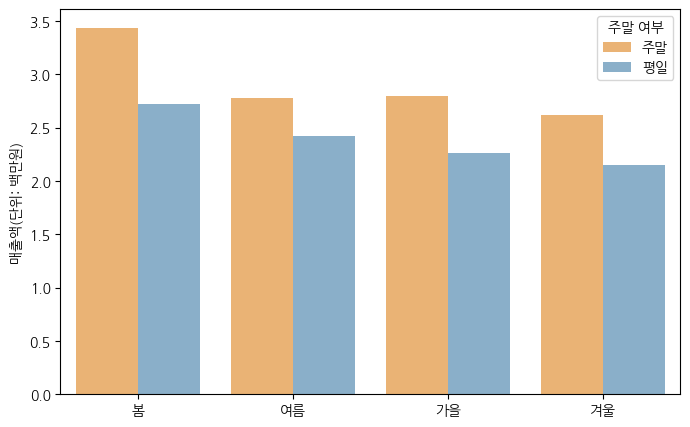

In [25]:
grouped_df = cp_data_df.groupby(['결제일', '계절', '주말 여부'])['매출'].sum().reset_index(name='매출')
season_grouped_df = grouped_df.groupby(['계절', '주말 여부'])['매출'].mean().reset_index(name='매출')

# 계절 순서 지정
season_order = ['봄', '여름', '가을', '겨울']
season_grouped_df['계절'] = pd.Categorical(season_grouped_df['계절'], categories=season_order, ordered=True)

# 단위설정
season_grouped_df['매출'] = season_grouped_df['매출']/1e6

# 시각화
plt.figure(figsize=(8, 5))

sns.barplot(data=season_grouped_df, x='계절', y='매출', hue='주말 여부', palette=colors1)
plt.xlabel('')
plt.ylabel('매출액(단위: 백만원)', fontsize=10)

plt.show()

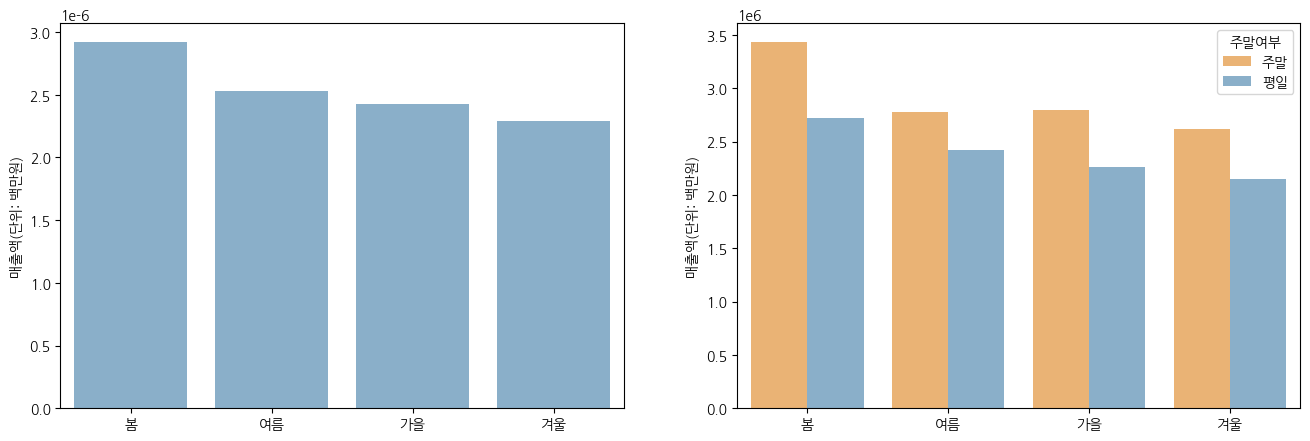

In [15]:
# 시간대 순서 지정
season_order = ['봄', '여름', '가을', '겨울']

# 평균 매출액 그룹화
grouped_df = cp_data_df.groupby(['결제일', '계절'])['매출'].sum().reset_index(name='매출')
season_grouped_df = grouped_df.groupby(['계절'])['매출'].mean().reset_index(name='매출')

season_grouped_df['계절'] = pd.Categorical(season_grouped_df['계절'], categories=season_order, ordered=True)

# 합계 매출액 그룹화 
grouped_df = cp_data_df.groupby(['결제일', '계절', '주말여부'])['매출'].sum().reset_index(name='매출')
season_day_grouped_df = grouped_df.groupby(['계절', '주말여부'])['매출'].mean().reset_index(name='매출')

season_day_grouped_df['계절'] = pd.Categorical(season_day_grouped_df['계절'], categories=season_order, ordered=True)

# 단위설정
season_grouped_df['매출'] = season_grouped_df['매출']/1e6
season_grouped_df['매출'] = season_grouped_df['매출']/1e6

# 시각화 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 평균 매출액
ax1 = axes[0]
sns.barplot(data=season_grouped_df, x='계절', y='매출', ax=ax1, color=colors1[1])


ax1.set_xlabel('')
ax1.set_ylabel('매출액(단위: 백만원)', fontsize=10)



# 합계 매출액 
ax2 = axes[1]
sns.barplot(data=season_day_grouped_df, x='계절', y='매출', ax=ax2, hue='주말여부', palette=colors1)

ax2.set_xlabel('')
ax2.set_ylabel('매출액(단위: 백만원)', fontsize=10)

plt.show()

# 방문인원단위 추정

In [59]:
tmp = cp_data_df[~cp_data_df['카테고리'].isin(['디저트','싱글원두', '블렌딩원두', '드립백/캡슐', '사업자', 'MD'])]
drink_categories = tmp[~tmp['카테고리'].isin(['디저트','싱글원두', '블렌딩원두', '드립백/캡슐', '사업자', 'MD'])]['카테고리'].unique()
print(drink_categories)
# tmp = tmp.groupby(['결제일시']).size().reset_index(name='방문 인원 단위')

tmp = tmp.groupby('결제일시').apply(lambda x: x[x['카테고리'].isin(drink_categories)].shape[0]).reset_index(name='방문 인원 단위')
visitor_counts = (tmp['방문 인원 단위'].value_counts().sort_index().reset_index())
# tmp.groupby('방문 인원 단위').size()
visitor_counts

['핸드드립' '에스프레소' '시그니처' 'Basic' '비버리지' '세트']


/var/folders/28/yfz0sdy50n5bhnthb4tg9j8m0000gn/T/ipykernel_56854/849322983.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = tmp.groupby('결제일시').apply(lambda x: x[x['카테고리'].isin(drink_categories)].shape[0]).reset_index(name='방문 인원 단위')


,방문 인원 단위,count
0,1,20997
1,2,31019
2,3,7685
3,4,2214
4,5,505
5,6,120
6,7,33
7,8,15
8,9,4
9,10,2


KeyError: '방문 인원 단위'

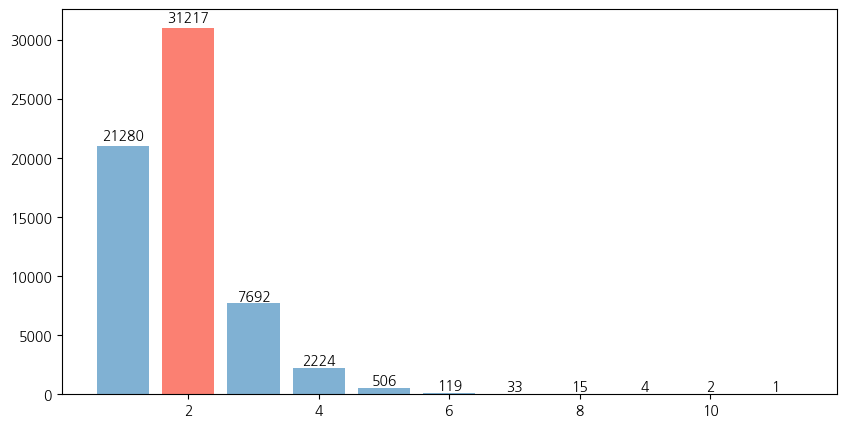

In [65]:
# 색상 지정
colors = [sns.color_palette("Set3")[3] if val == 2 else sns.color_palette("Set3")[4] for val in df["인원(가정)"]]

# 시각화 
plt.figure(figsize=(10, 5))
ax = plt.bar(visitor_counts["방문 인원 단위"], visitor_counts["count"], color=colors)

# 막대 위에 수치 표시
for bar, count in zip(ax, df["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, count + 300, f'{count}', ha='center')

# x축 눈금 수동 설정
plt.xticks(ticks=df["방문 인원 단위"], labels=df["방문 인원 단위"])

# 라벨 설정
plt.xlabel("방문 인원 단위")
plt.ylabel("방문 수")
plt.title("")
plt.figtext(0.5, -0.006, " [방문 인원 단위 추정]", fontsize=14, ha='center')

plt.show()

# 활용방안 차트


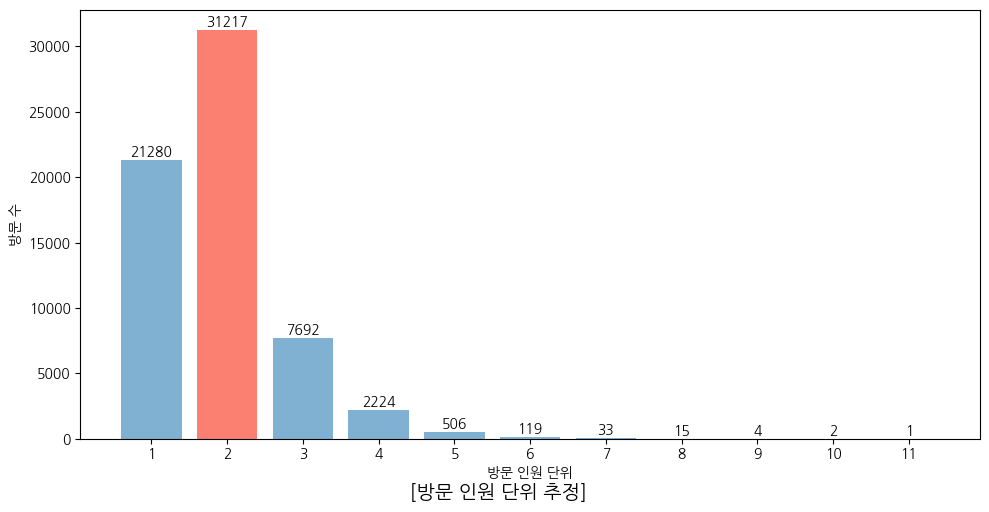

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.DataFrame({
    '인원(가정)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    'count': [21280, 31217, 7692, 2224, 506, 119, 33, 15, 4, 2, 1]
})

# 색상 지정: 인원이 2이면 Set3[3], 아니면 Set3[4]
colors = [sns.color_palette("Set3")[3] if val == 2 else sns.color_palette("Set3")[4] for val in df["인원(가정)"]]

# 시각화 설정
plt.figure(figsize=(10, 5))
bars = plt.bar(df["인원(가정)"], df["count"], color=colors)

# x축 눈금 수동 설정
plt.xticks(ticks=df["인원(가정)"], labels=df["인원(가정)"])

# 막대 위에 수치 표시
for bar, count in zip(bars, df["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, count + 300, f'{count}', ha='center')

# 라벨 설정
plt.xlabel("방문 인원 단위")
plt.ylabel("방문 수")
plt.title("")
plt.figtext(0.5, -0.006, " [방문 인원 단위 추정]", fontsize=14, ha='center')

plt.tight_layout()
plt.show()
